# IoT Device Behavior Anomaly Detection

**Objective:** Surface compromised or malfunctioning devices from telemetry frequency, payload, battery, errors, destinations, and uptime.

This notebook trains without labels. A small injected scenario flag is retained only to test the alerting workflow after scoring.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Generate normal behavior and rare stress scenarios


In [2]:
FEATURES = ["messages_per_hour", "payload_kb", "battery_drop_pct", "error_count", "destination_count", "uptime_hours"]
MEANS = np.asarray([72, 4.5, 1.4, 0.6, 2, 510], dtype=float)
STDS = np.asarray([11, 1.1, 0.5, 0.8, 0.9, 80], dtype=float)
SHIFTS = np.asarray([7, 8, 6, 10, 9, -5], dtype=float)

normal = rng.normal(MEANS, STDS, size=(960, len(FEATURES)))
stress = rng.normal(MEANS + SHIFTS * STDS, STDS * 0.55, size=(40, len(FEATURES)))
values = np.vstack([normal, stress])
values = np.maximum(values, 0)
data = pd.DataFrame(values, columns=FEATURES)
data["scenario_anomaly"] = np.r_[np.zeros(len(normal), dtype=int), np.ones(len(stress), dtype=int)]
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset: {len(data):,} windows | stress scenarios retained for retrospective checks: {data['scenario_anomaly'].sum()}")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset: 1,000 windows | stress scenarios retained for retrospective checks: 40


,messages_per_hour,payload_kb,battery_drop_pct,error_count,destination_count,uptime_hours,scenario_anomaly
0,71.530,4.954,1.037,0.896,2.602,456.425,0
1,56.361,3.735,0.898,1.182,2.154,398.759,0
2,75.665,2.126,1.381,0.000,2.091,423.781,0
3,86.405,5.974,1.658,0.236,1.784,445.668,0
4,67.154,5.955,1.731,0.613,1.585,475.341,0


,count,mean,std,min,25%,50%,75%,max
messages_per_hour,1000.0,75.020,18.685,38.197,65.240,72.543,79.989,165.399
payload_kb,1000.0,4.801,2.091,0.487,3.715,4.538,5.242,14.830
battery_drop_pct,1000.0,1.500,0.775,0.000,1.047,1.416,1.769,5.098
error_count,1000.0,1.039,1.672,0.000,0.113,0.630,1.279,10.012
destination_count,1000.0,2.334,1.809,0.000,1.433,2.048,2.684,10.889
uptime_hours,1000.0,492.369,109.377,29.774,445.723,508.450,557.236,764.389


## 3. Robust scaling and label-free detector fitting


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X = scaler.fit_transform(data[FEATURES])
contamination = 0.04

isolation = IsolationForest(n_estimators=240, contamination=contamination, random_state=RANDOM_STATE, n_jobs=1)
data["isolation_flag"] = (isolation.fit_predict(X) == -1).astype(int)
data["isolation_score"] = -isolation.score_samples(X)

lof = LocalOutlierFactor(n_neighbors=35, contamination=contamination)
data["lof_flag"] = (lof.fit_predict(X) == -1).astype(int)
data["lof_score"] = -lof.negative_outlier_factor_
print(f"Isolation Forest alerts: {data['isolation_flag'].sum()} | LOF alerts: {data['lof_flag'].sum()}")


Isolation Forest alerts: 40 | LOF alerts: 40


## 4. Retrospective detector diagnostics


In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

rows = []
for name in ["isolation", "lof"]:
    rows.append({
        "detector": name,
        "precision": precision_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "recall": recall_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "f1": f1_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "roc_auc_from_score": roc_auc_score(data["scenario_anomaly"], data[f"{name}_score"]),
    })
diagnostics = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(diagnostics.round(4))
print("Scenario labels were not used during scaling, detector fitting, or threshold selection.")


Scenario labels were not used during scaling, detector fitting, or threshold selection.


,detector,precision,recall,f1,roc_auc_from_score
0,isolation,1.0,1.0,1.0,1.0000
1,lof,0.0,0.0,0.0,0.2184


## 5. Alert queue and feature-level context


In [5]:
median = data[FEATURES].median()
mad = (data[FEATURES] - median).abs().median().replace(0, 1e-9)
robust_deviation = ((data[FEATURES] - median) / mad).abs()
data["largest_deviation_feature"] = robust_deviation.idxmax(axis=1)
data["largest_robust_deviation"] = robust_deviation.max(axis=1)
alerts = data.sort_values("isolation_score", ascending=False).head(12)
display(alerts[FEATURES + ["isolation_score", "largest_deviation_feature", "largest_robust_deviation", "scenario_anomaly"]].round(3))


,messages_per_hour,payload_kb,battery_drop_pct,error_count,destination_count,uptime_hours,isolation_score,largest_deviation_feature,largest_robust_deviation,scenario_anomaly
388,137.870,12.402,4.582,7.377,10.706,29.774,0.733,destination_count,13.846,1
561,143.155,12.411,4.462,9.310,10.201,49.158,0.715,error_count,14.812,1
251,154.102,12.762,4.688,10.012,8.975,140.597,0.714,error_count,16.009,1
569,162.750,13.424,4.187,8.781,9.867,48.659,0.704,error_count,13.909,1
662,140.237,14.051,4.287,7.983,10.889,107.037,0.700,destination_count,14.139,1
792,165.399,12.571,4.054,8.179,10.049,149.414,0.697,error_count,12.882,1
872,153.717,13.287,4.713,9.179,10.694,163.044,0.696,error_count,14.588,1
43,157.706,13.743,4.665,9.236,10.382,108.385,0.696,error_count,14.686,1
117,151.787,14.521,4.449,9.677,10.188,110.989,0.695,error_count,15.438,1
767,151.227,14.495,4.647,8.497,10.510,185.061,0.694,destination_count,13.532,1


## 6. Two-dimensional anomaly map


Detector score correlation: 0.4188


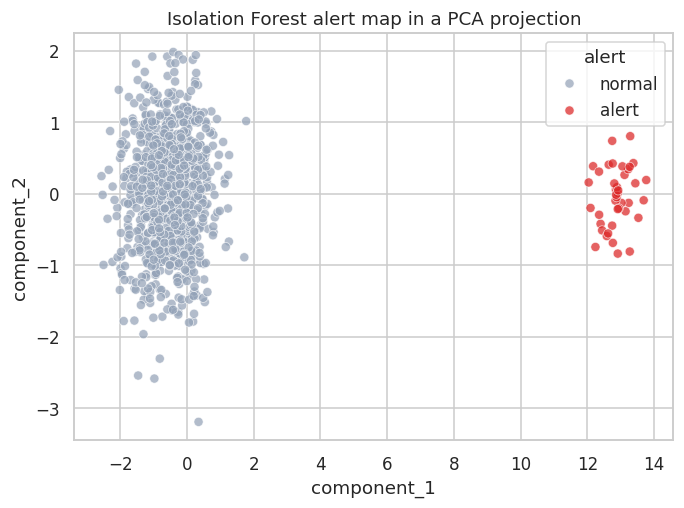

In [6]:
from sklearn.decomposition import PCA

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "alert": data["isolation_flag"].map({0: "normal", 1: "alert"})})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="alert", palette={"normal": "#94a3b8", "alert": "#dc2626"}, alpha=0.72)
plt.title("Isolation Forest alert map in a PCA projection")
plt.tight_layout()
plt.show()
print(f"Detector score correlation: {data[['isolation_score', 'lof_score']].corr().iloc[0, 1]:.4f}")


## 7. Findings and limitations

- Anomaly scores prioritize investigation; they do not prove malicious activity, failure, or waste.
- The injected stress cases demonstrate evaluation mechanics only.
- Production thresholds should be calibrated to alert capacity, missed-event cost, seasonality, and feedback from investigators.
